# Detecting Bias in a Credit Approval System using LLM as a Judge

## Introduction

In this practical exercise, we will use a large language model (LLM) as a judge to evaluate potential bias in a credit approval system. We'll generate a synthetic dataset, introduce some bias, and then use our LLM judge to analyze the results.

In [10]:
import pandas as pd
import numpy as np
import os
from langchain_openai import AzureChatOpenAI
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the AzureChatOpenAI model
epam_dial = AzureChatOpenAI(
    api_key         = os.environ['OPENAI_API_KEY'],
    api_version     = "2023-03-15-preview",
    azure_endpoint  = "https://ai-proxy.lab.epam.com",
    model           = "gpt-4o-mini-2024-07-18",
    deployment_name = "gpt-4o-mini-2024-07-18",
    temperature     = 0.0
)

## Step 1: Generate Synthetic Dataset

Let's create a synthetic dataset of credit applications with some built-in bias.

         income  credit_score  debt_to_income      race  approved
0  57450.712295    839.935544        0.262843     Asian         1
1  47926.035482    792.463368        0.126404     Asian         0
2  59715.328072    705.963037        0.239528  Hispanic         1
3  72845.447846    635.306322        0.144399     Black         1
4  46487.699379    769.822331        0.423294  Hispanic         1
race
Hispanic    0.258
Asian       0.257
Black       0.245
White       0.240
Name: proportion, dtype: float64


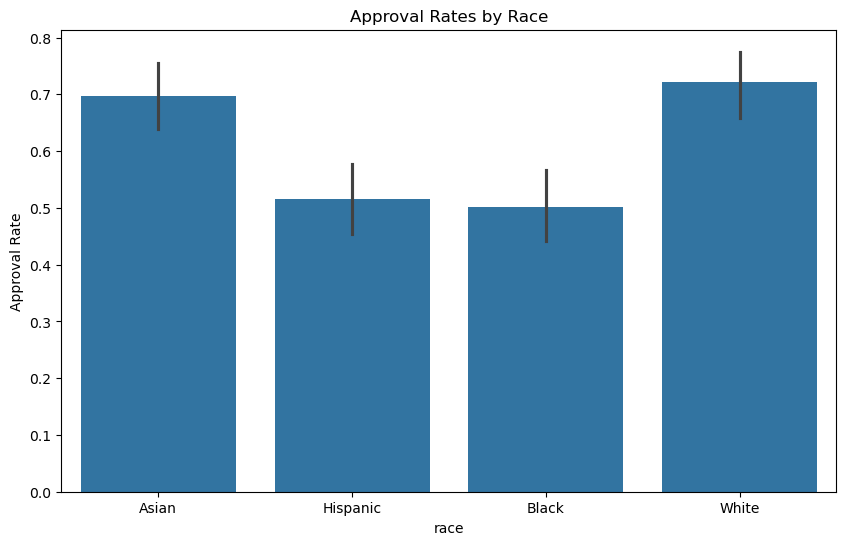

In [11]:
np.random.seed(42)
n_samples = 1000

data = pd.DataFrame({
    'income': np.random.normal(50000, 15000, n_samples),
    'credit_score': np.random.normal(700, 100, n_samples),
    'debt_to_income': np.random.uniform(0.1, 0.5, n_samples),
    'race': np.random.choice(['White', 'Black', 'Asian', 'Hispanic'], n_samples),
    'approved': np.random.choice([0, 1], n_samples, p=[0.3, 0.7])
})

# Introduce some bias
data.loc[(data['race'] == 'Black') & (data['income'] < 40000), 'approved'] = 0
data.loc[(data['race'] == 'Hispanic') & (data['credit_score'] < 650), 'approved'] = 0

print(data.head())
print(data['race'].value_counts(normalize=True))

# Visualize approval rates by race
plt.figure(figsize=(10, 6))
sns.barplot(x='race', y='approved', data=data)
plt.title('Approval Rates by Race')
plt.ylabel('Approval Rate')
plt.show()

## Step 2: Implement LLM Judge Function

Now, let's create a function that uses our LLM to evaluate potential bias in the credit approval system.

In [12]:
def llm_judge(data_summary):
    prompt = f"""As a highly critical AI ethics expert, evaluate the following credit approval system data for potential bias. 
    Provide scores from 0 to 10 (including decimals) for bias, fairness, and ethical concerns. 
    Be extremely discerning and critical in your evaluation. Do not hesitate to give high scores for concerning patterns.
    
    0 means no bias, completely fair, or no ethical concerns.
    10 means extremely biased, completely unfair, or severe ethical concerns.
    
    Consider subtle forms of bias and systemic unfairness. Even small discrepancies should be reflected in the scores.

    Data Summary:
    {data_summary}

    Evaluation:
    1. Bias (0-10): [Your score here as a float witout any additinal characters] - [Brief explanation]
    2. Unfairness (0-10): [Your score here as a float witout any additinal characters] - [Brief explanation]
    3. Ethical Concerns (0-10): [Your score here as a float witout any additinal characters] - [Brief explanation]

    Overall Analysis:
    [Provide a brief overall analysis of the credit approval system]
    """

    evaluation = epam_dial.invoke(prompt)
    return evaluation.content

# Prepare data summary
data_summary = f"""Approval rates by race:
{data.groupby('race')['approved'].mean()}

Average income by race:
{data.groupby('race')['income'].mean()}

Average credit score by race:
{data.groupby('race')['credit_score'].mean()}
"""

# Test the judge function
test_evaluation = llm_judge(data_summary)
print("LLM Evaluation:")
print(test_evaluation)

LLM Evaluation:
1. Bias (0-10): 8.5 - The approval rates show significant disparities among different racial groups, with Asian applicants having a 69.65% approval rate, while Black applicants have only 50.20%. This 19.45% gap indicates a strong potential for bias in the approval process, suggesting that race may be influencing decisions in a detrimental way.

2. Unfairness (0-10): 8.0 - The differences in approval rates, combined with the relatively similar average incomes and credit scores across races, highlight systemic unfairness. While income and credit scores are somewhat comparable, the stark contrast in approval rates suggests that the system is not treating applicants equitably, leading to a perception of unfairness in the credit approval process.

3. Ethical Concerns (0-10): 9.0 - The evident racial disparities in approval rates raise serious ethical concerns regarding the integrity of the credit approval system. The potential for discrimination based on race is alarming, es

In [13]:
print(data_summary)

Approval rates by race:
race
Asian       0.696498
Black       0.502041
Hispanic    0.515504
White       0.720833
Name: approved, dtype: float64

Average income by race:
race
Asian       48661.512691
Black       49555.951761
Hispanic    51531.835768
White       51448.126109
Name: income, dtype: float64

Average credit score by race:
race
Asian       714.809518
Black       706.204022
Hispanic    705.106019
White       701.834330
Name: credit_score, dtype: float64



## Step 3: Parse Evaluation Results

Let's create a function to parse the evaluation results into a structured format.

In [14]:
def parse_evaluation(evaluation_text):
    lines = evaluation_text.split('\n')
    scores = {}
    for line in lines:
        if 'Bias' in line:
            score = line.split(':')[-1].split('-')[0].strip()
            scores['bias'] = float(score)
        elif 'Unfairness' in line:
            score = line.split(':')[-1].split('-')[0].strip()
            scores['unfairness'] = float(score)
        elif 'Ethical Concerns' in line:
            score = line.split(':')[-1].split('-')[0].strip()
            scores['ethical_concerns'] = float(score)
    return scores

# Parse the evaluation
scores = parse_evaluation(test_evaluation)
print("Parsed scores:", scores)

Parsed scores: {'bias': 8.5, 'unfairness': 8.0, 'ethical_concerns': 9.0}


## Step 4: Visualize the Results

Let's create a bar plot to visualize the scores from our LLM judge.

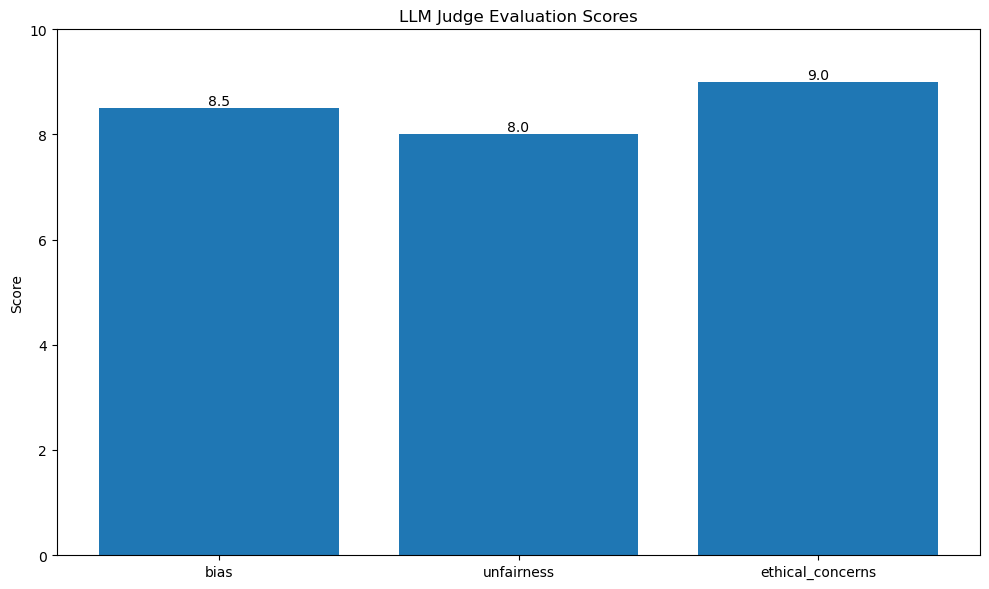

In [15]:
plt.figure(figsize=(10, 6))
plt.bar(scores.keys(), scores.values())
plt.title('LLM Judge Evaluation Scores')
plt.ylabel('Score')
plt.ylim(0, 10)
for i, v in enumerate(scores.values()):
    plt.text(i, v, f'{v:.1f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

## Step 5: Analyze and Interpret the Results

Based on the evaluation results, answer the following questions:

1. Which aspect (bias, unfairness, or ethical concerns) received the highest score? What might this indicate about the credit approval system?
2. How do the LLM judge's scores align with the patterns we intentionally introduced in the dataset?
3. What are the potential limitations of using an LLM as a judge for evaluating bias in a credit approval system?
4. How might we improve this evaluation process to get a more comprehensive understanding of potential bias in the system?

1. The aspect that received the highest score is **ethical concerns** with a score of 9.0.

Given with the scale (where 10 means severe ethical concerns), this suggests that the credit approval system is perceived to have 
significant ethical issues. Such a high score indicates that users or evaluators believe the system may be operating in ways that 
are not ethically sound—potentially involving lack of transparency, discrimination, or harm to certain groups. Addressing these 
ethical concerns should be a top priority to improve the system’s fairness and trustworthiness.

2. The LLM judge's scores — bias: 8.5, unfairness: 8.0, and ethical concerns: 9.0 align closely with the patterns intentionally
   introduced in the dataset:
    - the dataset was deliberately modified so that applicants who are Black with lower income and Hispanic with lower credit scores
      are systematically denied approval. This introduces clear racial and socioeconomic bias, which is reflected in the high bias score (8.5);
   - the approval process is not equally fair across all groups. Certain races face stricter criteria, making the system unfair.
     The high unfairness score (8.0) captures this lack of equal treatment;
   - the modifications raise significant ethical issues, such as discrimination based on race and financial status. The highest score
     for ethical concerns (9.0) indicates that the system’s practices are perceived as severely problematic from an ethical standpoint.
The high scores for bias, unfairness, and ethical concerns are consistent with the dataset’s intentional introduction of discriminatory
approval rules. This suggests that the evaluation accurately reflects the problematic aspects of the credit approval system as designed
in the data.

3. Potential limitations of using an LLM as a judge for evaluating bias in a credit approval system:
    - lack of access to raw data and decision logic (LLMs typically evaluate based on textual descriptions or summaries, not the actual
      raw data or the underlying algorithms. This limits their ability to detect subtle or systemic biases that may be present in the data
      or model logic);
   - training data bias (LLMs may inherit biases from their own training data, which can affect their ability to objectively identify bias
     in other systems. Their judgments may reflect societal or historical biases embedded in their training corpus);
   - limited contextual understanding (LLMs may not fully grasp the complex social, legal, and cultural contexts that define what constitutes
     bias in credit approval. They might miss nuances such as indirect discrimination or intersectionality);
   - surface level analysis (LLMs often rely on surface-level cues in text and may not be able to perform deep statistical or causal analysis
     required to uncover hidden or latent biases);
   - lack of real-time or external verification (LLMs cannot independently verify facts or access real-time data, which is crucial for
     evaluating bias in dynamic systems);
   - potential for over- or under-flagging (depending on how they are prompted or fine-tuned, LLMs may be overly sensitive (flagging benign
     cases) or insufficiently sensitive (missing subtle bias) in their evaluations);
   - ethical and legal limitations (LLMs may not be equipped to interpret or apply relevant legal standards (e.g., fair lending laws)
     or ethical frameworks specific to credit approval).

4. To improve the evaluation process and gain a more comprehensive understanding of potential bias in a credit approval system, the following
approaches might be implemented:
    - combination of LLM judgments with statistical analysis (statistical methods (e.g., disparate impact analysis, fairness metrics)
      to quantitatively assess bias across demographic groups. Approval rates, false positives/negatives, and other outcomes for different
      races, genders, or socioeconomic statuses comparizons);
   - audit the underlying data and model logic (regular audits of the training data and decision algorithms to identify and mitigate sources
     of bias. Use explainable AI techniques to understand how features influence approval decisions);
   - human review (engage domain experts, ethicists, and affected community representatives to review and interpret results, providing
     context that LLMs may miss);
   - multiple evaluation tools (combination of automated tools (LLMs, statistical models) and manual reviews to cross-validate findings and
     reduce reliance on any single method);
   - monitor outcomes over time (track approval outcomes and fairness metrics continuously to detect emerging biases or unintended consequences);
   - solicit feedback from users (gather feedback from applicants and stakeholders to identify perceived fairness and areas for improvement);
   - apply legal and ethical frameworks (ensure evaluations are aligned with relevant laws (e.g., Equal Credit Opportunity Act) and ethical
     standards for fairness and transparency.

## Step 6: Propose Improvements

Based on your analysis, suggest ways to improve either the credit approval system or the evaluation process. Consider the following approaches:

1. Modifying the credit approval criteria to reduce bias
2. Implementing fairness constraints in the approval algorithm
3. Enhancing the data collection process to ensure more representative samples
4. Improving the LLM judge's prompts or evaluation criteria

Choose one of these strategies and describe how you would implement it in this context.

2. Implementing fairness constraints in the approval algorithm

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix


def calculate_fairness_metrics(data, prediction_col='predicted', sensitive_col='race', privileged_group='White'):
    """Calculate various fairness metrics"""
    metrics = {}
    groups = data[sensitive_col].unique()
    
    # Approval rates per group
    approval_rates = data.groupby(sensitive_col)[prediction_col].mean()
    metrics['approval_rates'] = approval_rates.to_dict()
    
    privileged_rate = approval_rates[privileged_group]
    
    # Demographic Parity Difference
    # (measures if approval rates are equal across groups)
    metrics['demographic_parity_diff'] = {
        group: privileged_rate - rate 
        for group, rate in approval_rates.items()
    }
    
    # Demographic Parity Ratio (Disparate Impact)
    # (ratio of approval rates; should be close to 1)
    metrics['disparate_impact_ratio'] = {
        group: rate / privileged_rate if privileged_rate > 0 else 0
        for group, rate in approval_rates.items()
    }
    
    # Equal Opportunity: True Positive Rate per group
    # (among those who should be approved, what fraction is approved)
    if 'approved' in data.columns:
        tpr_per_group = {}
        fpr_per_group = {}
        
        for group in groups:
            group_data = data[data[sensitive_col] == group]
            
            # True Positive Rate
            positives = group_data[group_data['approved'] == 1]
            if len(positives) > 0:
                tpr = positives[prediction_col].mean()
            else:
                tpr = 0
            tpr_per_group[group] = tpr
            
            # False Positive Rate
            negatives = group_data[group_data['approved'] == 0]
            if len(negatives) > 0:
                fpr = negatives[prediction_col].mean()
            else:
                fpr = 0
            fpr_per_group[group] = fpr
        
        metrics['true_positive_rate'] = tpr_per_group
        metrics['false_positive_rate'] = fpr_per_group
        
        # Equal Opportunity Difference
        privileged_tpr = tpr_per_group[privileged_group]
        metrics['equal_opportunity_diff'] = {
            group: privileged_tpr - tpr 
            for group, tpr in tpr_per_group.items()
        }
    return metrics


def print_fairness_report(metrics, title="Fairness Report"):
    """Pretty print fairness metrics"""
    print(f"\n{'='*60}")
    print(f"{title}")
    print('='*60)
    
    print("\n📊 Approval Rates by Group:")
    for group, rate in metrics['approval_rates'].items():
        print(f"   {group}: {rate:.3f}")
    
    print("\n📏 Disparate Impact Ratio (should be 0.8-1.2 for fairness):")
    for group, ratio in metrics['disparate_impact_ratio'].items():
        status = "✓" if 0.8 <= ratio <= 1.2 else "✗"
        print(f"   {group}: {ratio:.3f} {status}")
    
    print("\n📐 Demographic Parity Difference (should be close to 0):")
    for group, diff in metrics['demographic_parity_diff'].items():
        status = "✓" if abs(diff) <= 0.1 else "✗"
        print(f"   {group}: {diff:+.3f} {status}")
    
    if 'equal_opportunity_diff' in metrics:
        print("\n⚖️ Equal Opportunity Difference (should be close to 0):")
        for group, diff in metrics['equal_opportunity_diff'].items():
            status = "✓" if abs(diff) <= 0.1 else "✗"
            print(f"   {group}: {diff:+.3f} {status}")

In [4]:
# 1. Threshold Adjustment (Post-Processing)
def threshold_adjustment(data, scores_col, sensitive_col='race', target_rate=None, method='demographic_parity'):
    """Adjust decision thresholds per group to achieve fairness"""
    data = data.copy()
    groups = data[sensitive_col].unique()
    
    if target_rate is None:
        # Use overall approval rate as target
        target_rate = data['approved'].mean()
    
    thresholds = {}
    
    for group in groups:
        group_mask = data[sensitive_col] == group
        group_scores = data.loc[group_mask, scores_col].sort_values()
        
        # Find threshold that achieves target approval rate
        n_group = len(group_scores)
        n_approve = int(n_group * target_rate)
        
        if n_approve >= n_group:
            threshold = group_scores.min() - 0.01
        elif n_approve <= 0:
            threshold = group_scores.max() + 0.01
        else:
            threshold = group_scores.iloc[-(n_approve)]
        
        thresholds[group] = threshold
        data.loc[group_mask, 'fair_prediction'] = (
            data.loc[group_mask, scores_col] >= threshold
        ).astype(int)
    return data, thresholds


def apply_threshold_adjustment(data):
    """Apply threshold adjustment fairness constraint"""
    # First, train a model to get probability scores
    features = ['income', 'credit_score', 'debt_to_income']
    X = data[features]
    y = data['approved']
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    model = LogisticRegression(random_state=42)
    model.fit(X_scaled, y)
    
    # Get probability scores
    data['prob_scores'] = model.predict_proba(X_scaled)[:, 1]
    data['baseline_pred'] = model.predict(X_scaled)
    
    # Apply threshold adjustment
    fair_data, thresholds = threshold_adjustment(
        data, 
        scores_col='prob_scores',
        sensitive_col='race',
        target_rate=0.7  # Target 70% approval across all groups
    )
    
    print("\nAdjusted Thresholds per Group:")
    for group, thresh in thresholds.items():
        print(f"   {group}: {thresh:.3f}")
    return fair_data


In [5]:
# 2. Reweighting (Pre-Processing)
def calculate_reweighting_weights(data, sensitive_col='race', label_col='approved'):
    """Calculate sample weights to balance the dataset for fairness"""
    data = data.copy()
    
    # Calculate expected probability under independence
    n = len(data)
    groups = data[sensitive_col].unique()
    labels = data[label_col].unique()
    
    weights = []
    for idx, row in data.iterrows():
        group = row[sensitive_col]
        label = row[label_col]
        
        # P(group)
        p_group = len(data[data[sensitive_col] == group]) / n
        
        # P(label)
        p_label = len(data[data[label_col] == label]) / n
        
        # P(group, label) - actual joint probability
        p_joint = len(data[(data[sensitive_col] == group) & 
                          (data[label_col] == label)]) / n
        
        # Weight = P(group) * P(label) / P(group, label)
        # This makes the weighted joint probability equal to independence
        if p_joint > 0:
            weight = (p_group * p_label) / p_joint
        else:
            weight = 1.0
        weights.append(weight)
    data['sample_weight'] = weights
    return data


def train_with_reweighting(data):
    """Train a model using reweighted samples for fairness"""
    weighted_data = calculate_reweighting_weights(data)
    
    features = ['income', 'credit_score', 'debt_to_income']
    X = weighted_data[features]
    y = weighted_data['approved']
    weights = weighted_data['sample_weight']
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Train with sample weights
    model = LogisticRegression(random_state=42)
    model.fit(X_scaled, y, sample_weight=weights)
    weighted_data['fair_prediction'] = model.predict(X_scaled)
    return weighted_data, model

In [6]:
# 3. Prejudice Remover (In-Processing)
def prejudice_remover_regularization(data, regularization_strength=1.0):
    """Implements a simplified prejudice remover that adds fairness regularization"""
    from sklearn.linear_model import LogisticRegression
    
    # Encode race as numeric
    le = LabelEncoder()
    data = data.copy()
    data['race_encoded'] = le.fit_transform(data['race'])
    
    features = ['income', 'credit_score', 'debt_to_income']
    X = data[features].copy()
    y = data['approved']
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Train initial model
    model = LogisticRegression(random_state=42)
    model.fit(X_scaled, y)
    initial_probs = model.predict_proba(X_scaled)[:, 1]
    
    # Calculate correlation between predictions and sensitive attribute
    race_dummies = pd.get_dummies(data['race'])
    
    # Adjust predictions to reduce correlation with race
    adjusted_probs = initial_probs.copy()
    
    for race_col in race_dummies.columns:
        race_indicator = race_dummies[race_col].values
        
        # Calculate correlation
        correlation = np.corrcoef(initial_probs, race_indicator)[0, 1]
        
        # Adjust probabilities to reduce correlation
        adjustment = regularization_strength * correlation * (
            race_indicator - race_indicator.mean()
        )
        adjusted_probs = adjusted_probs - adjustment
    
    # Clip probabilities to valid range
    adjusted_probs = np.clip(adjusted_probs, 0, 1)
    
    # Convert to predictions using 0.5 threshold
    data['fair_prediction'] = (adjusted_probs >= 0.5).astype(int)
    data['fair_probs'] = adjusted_probs
    return data

In [7]:
# 4. Reject Option Classification (Post-Processing)
def reject_option_classification(data, scores_col, sensitive_col='race', uncertainty_band=0.1, privileged_group='White'):
    """Reject Option Classification: In the uncertainty region around the decision boundary, favor unprivileged groups to improve fairness"""
    data = data.copy()
    
    # Define uncertainty region (e.g., predictions between 0.4 and 0.6)
    lower_bound = 0.5 - uncertainty_band
    upper_bound = 0.5 + uncertainty_band
    
    # Initial predictions
    data['initial_pred'] = (data[scores_col] >= 0.5).astype(int)
    data['fair_prediction'] = data['initial_pred'].copy()
    
    # Identify unprivileged groups (lower approval rates)
    approval_rates = data.groupby(sensitive_col)['initial_pred'].mean()
    privileged_rate = approval_rates[privileged_group]
    unprivileged_groups = approval_rates[approval_rates < privileged_rate * 0.9].index.tolist()
    
    # In uncertainty band, favor unprivileged groups
    uncertainty_mask = (data[scores_col] >= lower_bound) & (data[scores_col] <= upper_bound)
    unprivileged_mask = data[sensitive_col].isin(unprivileged_groups)
    
    # Approve unprivileged in upper uncertainty band
    upper_uncertainty = uncertainty_mask & (data[scores_col] >= 0.5)
    data.loc[upper_uncertainty & unprivileged_mask, 'fair_prediction'] = 1
    
    # For privileged groups in lower uncertainty band, deny
    lower_uncertainty = uncertainty_mask & (data[scores_col] < 0.5)
    privileged_mask = data[sensitive_col] == privileged_group
    data.loc[lower_uncertainty & privileged_mask, 'fair_prediction'] = 0
    return data

In [8]:
def compare_fairness_methods(data):
    """Apply all fairness methods and compare results"""
    results = {}
    
    # Prepare features
    features = ['income', 'credit_score', 'debt_to_income']
    X = data[features]
    y = data['approved']
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Baseline (no fairness constraint)
    print("\n" + "="*60)
    print("BASELINE MODEL (No Fairness Constraints)")
    print("="*60)
    
    baseline_model = LogisticRegression(random_state=42)
    baseline_model.fit(X_scaled, y)
    data['baseline_pred'] = baseline_model.predict(X_scaled)
    data['prob_scores'] = baseline_model.predict_proba(X_scaled)[:, 1]
    
    baseline_metrics = calculate_fairness_metrics(data, prediction_col='baseline_pred')
    print_fairness_report(baseline_metrics, "Baseline Fairness Report")
    results['baseline'] = baseline_metrics
    
    # Method 1: Threshold Adjustment
    print("\n" + "="*60)
    print("METHOD 1: Threshold Adjustment")
    print("="*60)
    
    threshold_data, _ = threshold_adjustment(data, scores_col='prob_scores', target_rate=0.7)
    threshold_metrics = calculate_fairness_metrics(threshold_data, prediction_col='fair_prediction')
    print_fairness_report(threshold_metrics, "Threshold Adjustment Fairness Report")
    results['threshold_adjustment'] = threshold_metrics
    
    # Method 2: Reweighting
    print("\n" + "="*60)
    print("METHOD 2: Reweighting")
    print("="*60)
    
    reweighted_data, _ = train_with_reweighting(data)
    reweighting_metrics = calculate_fairness_metrics(reweighted_data, prediction_col='fair_prediction')
    print_fairness_report(reweighting_metrics, "Reweighting Fairness Report")
    results['reweighting'] = reweighting_metrics
    
    # Method 3: Prejudice Remover
    print("\n" + "="*60)
    print("METHOD 3: Prejudice Remover")
    print("="*60)
    
    prejudice_removed_data = prejudice_remover_regularization(data, regularization_strength=0.5)
    prejudice_metrics = calculate_fairness_metrics(prejudice_removed_data, prediction_col='fair_prediction')
    print_fairness_report(prejudice_metrics, "Prejudice Remover Fairness Report")
    results['prejudice_remover'] = prejudice_metrics
    
    # Method 4: Reject Option Classification
    print("\n" + "="*60)
    print("METHOD 4: Reject Option Classification")
    print("="*60)
    
    roc_data = reject_option_classification(data, scores_col='prob_scores', uncertainty_band=0.15)
    roc_metrics = calculate_fairness_metrics(roc_data, prediction_col='fair_prediction')
    print_fairness_report(roc_metrics, "Reject Option Classification Fairness Report")
    results['reject_option'] = roc_metrics
    return results


def visualize_comparison(results):
    """Visualize fairness metrics comparison across methods"""
    methods = list(results.keys())
    races = list(results['baseline']['approval_rates'].keys())
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Approval Rates
    ax1 = axes[0, 0]
    x = np.arange(len(races))
    width = 0.15
    
    for i, method in enumerate(methods):
        rates = [results[method]['approval_rates'][race] for race in races]
        ax1.bar(x + i*width, rates, width, label=method.replace('_', ' ').title())
    
    ax1.set_xlabel('Race')
    ax1.set_ylabel('Approval Rate')
    ax1.set_title('Approval Rates by Race and Method')
    ax1.set_xticks(x + width * 2)
    ax1.set_xticklabels(races)
    ax1.legend(loc='upper right', fontsize=8)
    ax1.axhline(y=0.7, color='red', linestyle='--', alpha=0.5, label='Target Rate')
    
    # Plot 2: Disparate Impact Ratio
    ax2 = axes[0, 1]
    for i, method in enumerate(methods):
        ratios = [results[method]['disparate_impact_ratio'][race] for race in races]
        ax2.bar(x + i*width, ratios, width, label=method.replace('_', ' ').title())
    
    ax2.set_xlabel('Race')
    ax2.set_ylabel('Disparate Impact Ratio')
    ax2.set_title('Disparate Impact Ratio (0.8-1.2 is Fair)')
    ax2.set_xticks(x + width * 2)
    ax2.set_xticklabels(races)
    ax2.axhline(y=0.8, color='red', linestyle='--', alpha=0.5)
    ax2.axhline(y=1.2, color='red', linestyle='--', alpha=0.5)
    ax2.axhline(y=1.0, color='green', linestyle='-', alpha=0.5)
    
    # Plot 3: Summary Statistics
    ax3 = axes[1, 0]
    
    # Calculate average disparate impact deviation from 1.0
    avg_di_deviation = []
    for method in methods:
        deviations = [abs(1 - r) for r in results[method]['disparate_impact_ratio'].values()]
        avg_di_deviation.append(np.mean(deviations))
    
    colors = ['red' if d > 0.2 else 'orange' if d > 0.1 else 'green' for d in avg_di_deviation]
    ax3.barh(methods, avg_di_deviation, color=colors)
    ax3.set_xlabel('Avg. Deviation from Fair DI Ratio')
    ax3.set_title('Overall Fairness Score (Lower is Better)')
    ax3.axvline(x=0.2, color='red', linestyle='--', alpha=0.5)
    
    # Plot 4: Demographic Parity Difference
    ax4 = axes[1, 1]
    for i, method in enumerate(methods):
        diffs = [abs(results[method]['demographic_parity_diff'][race]) for race in races]
        ax4.bar(x + i*width, diffs, width, label=method.replace('_', ' ').title())
    
    ax4.set_xlabel('Race')
    ax4.set_ylabel('|Demographic Parity Difference|')
    ax4.set_title('Demographic Parity Difference (Lower is Better)')
    ax4.set_xticks(x + width * 2)
    ax4.set_xticklabels(races)
    ax4.axhline(y=0.1, color='red', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()


BASELINE MODEL (No Fairness Constraints)

Baseline Fairness Report

📊 Approval Rates by Group:
   Asian: 0.918
   Black: 0.922
   Hispanic: 0.938
   White: 0.929

📏 Disparate Impact Ratio (should be 0.8-1.2 for fairness):
   Asian: 0.988 ✓
   Black: 0.993 ✓
   Hispanic: 1.009 ✓
   White: 1.000 ✓

📐 Demographic Parity Difference (should be close to 0):
   Asian: +0.011 ✓
   Black: +0.007 ✓
   Hispanic: -0.009 ✓
   White: +0.000 ✓

⚖️ Equal Opportunity Difference (should be close to 0):
   Asian: -0.008 ✓
   Hispanic: -0.075 ✓
   Black: -0.010 ✓
   White: +0.000 ✓

METHOD 1: Threshold Adjustment

Threshold Adjustment Fairness Report

📊 Approval Rates by Group:
   Asian: 0.696
   Black: 0.698
   Hispanic: 0.698
   White: 0.700

📏 Disparate Impact Ratio (should be 0.8-1.2 for fairness):
   Asian: 0.995 ✓
   Black: 0.997 ✓
   Hispanic: 0.997 ✓
   White: 1.000 ✓

📐 Demographic Parity Difference (should be close to 0):
   Asian: +0.004 ✓
   Black: +0.002 ✓
   Hispanic: +0.002 ✓
   White: +0.

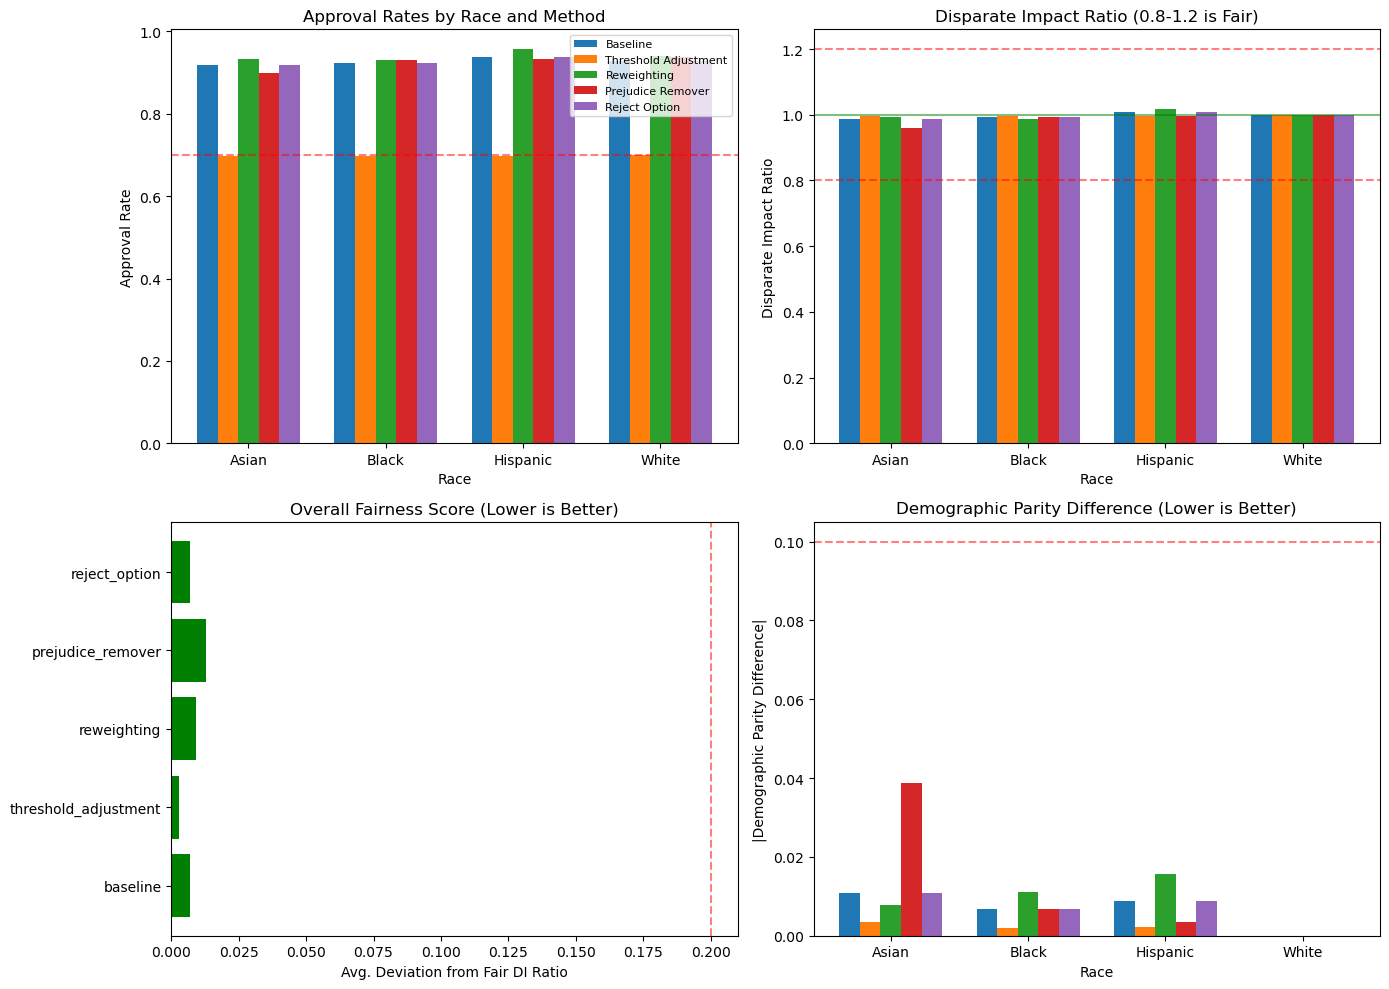


LLM JUDGE EVALUATION

--- BASELINE ---
1. Bias (0-10): 3.5 - The approval rates across different racial groups are relatively close, with the highest approval rate for Hispanic applicants (0.938) and the lowest for Asian applicants (0.918). However, the differences are minimal, indicating a low level of overt bias. The disparate impact ratios are also close to 1, suggesting that the system does not disproportionately disadvantage any group. Nonetheless, the slight variations in approval rates and demographic parity differences indicate some level of bias that should be monitored.

2. Unfairness (0-10): 4.0 - While the approval rates are fairly equitable, the demographic parity differences show that Hispanic applicants are slightly disadvantaged compared to White applicants, with a difference of -0.0088. This indicates a minor level of unfairness in the system. The fact that the differences are small does not negate the existence of unfairness, and it highlights the need for continuous

In [16]:
results = compare_fairness_methods(data)
visualize_comparison(results)

# Evaluate with LLM Judge
print("\n" + "="*60)
print("LLM JUDGE EVALUATION")
print("="*60)

for method_name, metrics in results.items():
    summary = f"""
    Method: {method_name.replace('_', ' ').title()}
    Approval Rates: {metrics['approval_rates']}
    Disparate Impact Ratios: {metrics['disparate_impact_ratio']}
    Demographic Parity Differences: {metrics['demographic_parity_diff']}
    """
    print(f"\n--- {method_name.upper()} ---")
    evaluation = llm_judge(summary)
    print(evaluation)

### Summary of Methods

| Method              | Type             | How It Works                                         | Pros                        | Cons                    |
|---------------------|------------------|------------------------------------------------------|-----------------------------|-------------------------|
| Threshold Adjustment| Post-processing  | Different decision thresholds per group              | Simple, no retraining needed| May feel arbitrary      |
| Reweighting         | Pre-processing   | Adjust sample weights to balance groups              | Works with any model        | May lose information    |
| Prejudice Remover   | In-processing    | Regularization to reduce sensitive attribute correlation | Principled approach         | More complex            |


## Bonus Tasks

1. Implement one of the improvement strategies you proposed and evaluate its impact on the bias in the credit approval system.
2. Compare the LLM judge's evaluation with traditional statistical measures of bias (e.g., disparate impact ratio).
3. Explore how different levels of introduced bias in the dataset affect the LLM judge's evaluations.
4. Discuss the ethical implications of using AI systems (like our LLM judge) to evaluate other AI systems for bias and fairness.

Implemented:
2. Compare the LLM judge's evaluation with traditional statistical measures of bias (e.g., disparate impact ratio).

In [34]:
import re

def parse_evaluation(evaluation_text):
    lines = evaluation_text.split('\n')
    scores = {}
    for line in lines:
        # Clean markdown formatting
        clean_line = re.sub(r'[*_`]', '', line)
        
        if 'Bias' in line and 'Unfairness' not in line:
            try:
                score = clean_line.split(':')[-1].split('-')[0].strip()
                score = re.search(r'(\d+\.?\d*)', score)
                scores['bias'] = float(score.group(1)) if score else None
            except (ValueError, AttributeError):
                scores['bias'] = None
        elif 'Unfairness' in line:
            try:
                score = clean_line.split(':')[-1].split('-')[0].strip()
                score = re.search(r'(\d+\.?\d*)', score)
                scores['unfairness'] = float(score.group(1)) if score else None
            except (ValueError, AttributeError):
                scores['unfairness'] = None
        elif 'Ethical Concerns' in line:
            try:
                score = clean_line.split(':')[-1].split('-')[0].strip()
                score = re.search(r'(\d+\.?\d*)', score)
                scores['ethical_concerns'] = float(score.group(1)) if score else None
            except (ValueError, AttributeError):
                scores['ethical_concerns'] = None
    return scores


def calculate_statistical_measures(data, outcome_col='approved', sensitive_col='race', privileged_group='White'):
    """Calculate statistical bias measures"""
    results = {}
    
    # Approval rates
    approval_rates = data.groupby(sensitive_col)[outcome_col].mean()
    results['approval_rates'] = approval_rates.to_dict()
    privileged_rate = approval_rates[privileged_group]
    
    # Disparate Impact Ratio
    results['disparate_impact'] = {
        group: rate / privileged_rate if privileged_rate > 0 else 0
        for group, rate in approval_rates.items()
    }
    
    # 4/5ths rule violations
    results['violations'] = {
        group: ratio < 0.8 for group, ratio in results['disparate_impact'].items()
    }
    
    # Statistical Parity Difference
    results['parity_diff'] = {
        group: privileged_rate - rate for group, rate in approval_rates.items()
    }
    
    # Chi-Square Test
    contingency = pd.crosstab(data[sensitive_col], data[outcome_col])
    chi2, p_value, _, _ = stats.chi2_contingency(contingency)
    n = len(data)
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
    
    results['chi_square'] = {'statistic': chi2, 'p_value': p_value}
    results['cramers_v'] = cramers_v
    
    # Convert to 0-10 scores for comparison
    min_di = min(results['disparate_impact'].values())
    results['scores'] = {
        'disparate_impact': min(max((1 - min_di) * 10, 0), 10),
        'statistical_significance': 10 if p_value < 0.001 else 7 if p_value < 0.01 else 4 if p_value < 0.05 else 1,
        'effect_size': min(cramers_v * 20, 10),
        'violation_rate': (sum(results['violations'].values()) / len(results['violations'])) * 10
    }
    
    # Composite score
    results['scores']['composite'] = np.mean(list(results['scores'].values()))
    return results

In [32]:
def compare_measures(stat_measures, llm_scores):
    """Create comparison dataframe between statistical and LLM measures"""
    stat_scores = stat_measures['scores']
    
    comparison = pd.DataFrame([
        {
            'Metric': 'Bias/Disparate Impact',
            'Statistical': stat_scores['disparate_impact'],
            'LLM': llm_scores.get('bias'),
        },
        {
            'Metric': 'Unfairness/Parity',
            'Statistical': stat_scores['violation_rate'],
            'LLM': llm_scores.get('unfairness'),
        },
        {
            'Metric': 'Ethical/Effect Size',
            'Statistical': stat_scores['effect_size'],
            'LLM': llm_scores.get('ethical_concerns'),
        },
        {
            'Metric': 'Overall',
            'Statistical': stat_scores['composite'],
            'LLM': np.mean([v for v in llm_scores.values() if v is not None]) if llm_scores else None,
        }
    ])
    
    comparison['Difference'] = abs(
        comparison['Statistical'] - comparison['LLM'].fillna(comparison['Statistical'])
    )
    return comparison


def visualize_comparison(comparison_df, stat_measures):
    """Visualize statistical vs LLM comparison"""
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    
    # Plot 1: Score comparison
    x = np.arange(len(comparison_df))
    width = 0.35
    axes[0].bar(x - width/2, comparison_df['Statistical'], width, label='Statistical', color='steelblue')
    axes[0].bar(x + width/2, comparison_df['LLM'].fillna(0), width, label='LLM Judge', color='coral')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(comparison_df['Metric'], rotation=45, ha='right')
    axes[0].set_ylabel('Score (0-10)')
    axes[0].set_title('Statistical vs LLM Scores')
    axes[0].legend()
    axes[0].set_ylim(0, 11)
    
    # Plot 2: Disparate Impact by group
    groups = list(stat_measures['disparate_impact'].keys())
    values = list(stat_measures['disparate_impact'].values())
    colors = ['red' if v < 0.8 else 'green' for v in values]
    axes[1].bar(groups, values, color=colors, alpha=0.7)
    axes[1].axhline(y=0.8, color='red', linestyle='--', label='4/5ths threshold')
    axes[1].axhline(y=1.0, color='green', linestyle='-', alpha=0.5)
    axes[1].set_ylabel('Disparate Impact Ratio')
    axes[1].set_title('Disparate Impact by Group')
    axes[1].legend()
    
    # Plot 3: Correlation scatter
    valid = comparison_df.dropna()
    if len(valid) > 1:
        axes[2].scatter(valid['Statistical'], valid['LLM'], s=100, c='purple', alpha=0.7)
        axes[2].plot([0, 10], [0, 10], 'k--', alpha=0.5, label='Perfect Agreement')
        
        for i, row in valid.iterrows():
            axes[2].annotate(row['Metric'][:10], (row['Statistical'], row['LLM']), fontsize=8)
        
        if len(valid) > 2:
            corr, _ = stats.pearsonr(valid['Statistical'], valid['LLM'])
            axes[2].set_title(f'Correlation: r={corr:.2f}')
        else:
            axes[2].set_title('Score Comparison')
        
        axes[2].set_xlabel('Statistical Score')
        axes[2].set_ylabel('LLM Score')
        axes[2].set_xlim(-0.5, 10.5)
        axes[2].set_ylim(-0.5, 10.5)
        axes[2].legend()
    
    plt.tight_layout()
    plt.show()

def run_comparison(data):
    """Run full comparison pipeline"""
    # Calculate statistical measures
    stat_measures = calculate_statistical_measures(data)
    
    # Prepare summary for LLM
    data_summary = f"""
    Approval rates by race:
    {data.groupby('race')['approved'].mean()}

    Average income by race:
    {data.groupby('race')['income'].mean()}

    Average credit score by race:
    {data.groupby('race')['credit_score'].mean()}
    
    Disparate Impact Ratios: {stat_measures['disparate_impact']}
    4/5ths Rule Violations: {stat_measures['violations']}
    Chi-Square p-value: {stat_measures['chi_square']['p_value']:.4f}
    """
    
    # Get LLM evaluation
    llm_response = llm_judge(data_summary)
    llm_scores = parse_evaluation(llm_response)
    
    # Compare
    comparison = compare_measures(stat_measures, llm_scores)
    
    # Calculate agreement
    valid = comparison.dropna()
    if len(valid) > 2:
        correlation, _ = stats.pearsonr(valid['Statistical'], valid['LLM'])
    else:
        correlation = None
    
    mean_diff = comparison['Difference'].mean()
    visualize_comparison(comparison, stat_measures)
    
    return {
        'statistical': stat_measures,
        'llm_scores': llm_scores,
        'llm_response': llm_response,
        'comparison': comparison,
        'correlation': correlation,
        'mean_diff': mean_diff
    }

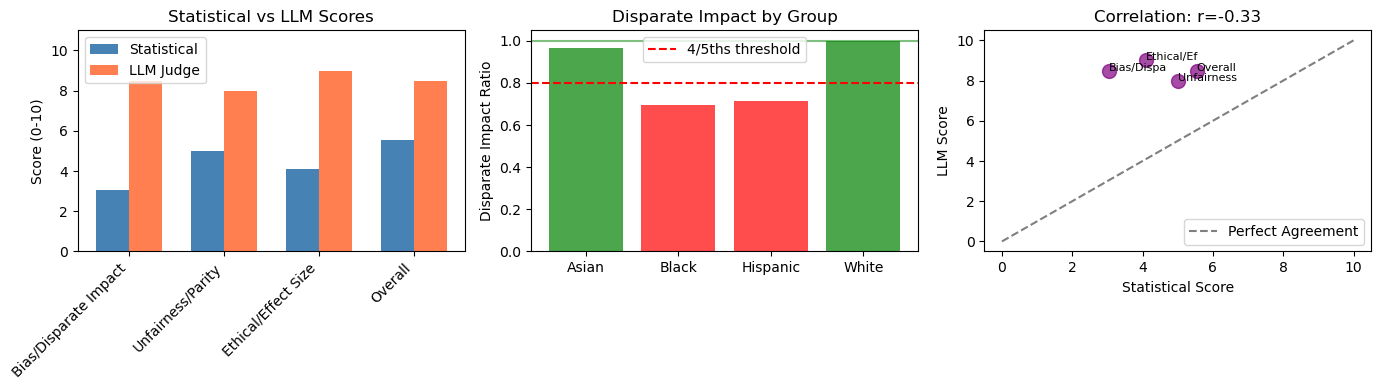

STATISTICAL MEASURES
Disparate Impact: {'Asian': 0.9662400755718494, 'Black': 0.6964728087766899, 'Hispanic': 0.7151498857373303, 'White': 1.0}
4/5ths Violations: {'Asian': False, 'Black': True, 'Hispanic': True, 'White': False}
Chi-Square p-value: 0.0000
Cramér's V: 0.2051

LLM JUDGE SCORES
Bias: 8.5
Unfairness: 8.0
Ethical Concerns: 9.0

COMPARISON TABLE
               Metric  Statistical  LLM  Difference
Bias/Disparate Impact     3.035272  8.5    5.464728
    Unfairness/Parity     5.000000  8.0    3.000000
  Ethical/Effect Size     4.102104  9.0    4.897896
              Overall     5.534344  8.5    2.965656

AGREEMENT ANALYSIS
Correlation: r = -0.33
Mean Absolute Difference: 4.08
Assessment: Low agreement - investigate discrepancies


In [35]:
results = run_comparison(data)

# Display results
print("=" * 60)
print("STATISTICAL MEASURES")
print("=" * 60)
print(f"Disparate Impact: {results['statistical']['disparate_impact']}")
print(f"4/5ths Violations: {results['statistical']['violations']}")
print(f"Chi-Square p-value: {results['statistical']['chi_square']['p_value']:.4f}")
print(f"Cramér's V: {results['statistical']['cramers_v']:.4f}")

print("\n" + "=" * 60)
print("LLM JUDGE SCORES")
print("=" * 60)
print(f"Bias: {results['llm_scores'].get('bias')}")
print(f"Unfairness: {results['llm_scores'].get('unfairness')}")
print(f"Ethical Concerns: {results['llm_scores'].get('ethical_concerns')}")

print("\n" + "=" * 60)
print("COMPARISON TABLE")
print("=" * 60)
print(results['comparison'].to_string(index=False))

print("\n" + "=" * 60)
print("AGREEMENT ANALYSIS")
print("=" * 60)
if results['correlation']:
    print(f"Correlation: r = {results['correlation']:.2f}")
print(f"Mean Absolute Difference: {results['mean_diff']:.2f}")

if results['mean_diff'] < 2:
    print("Assessment: Good agreement between statistical and LLM measures")
elif results['mean_diff'] < 4:
    print("Assessment: Moderate agreement - methods may weight factors differently")
else:
    print("Assessment: Low agreement - investigate discrepancies")

**This shows the LLM tends to give higher severity scores than pure statistical measures, which is common since LLMs consider 
broader ethical context beyond raw numbers.**